# Some Specific Examples

Version 0.1.0 can only treat adiabatic initial condition and radiation dominated era. The upcoming new version will have the abililty to treat isocurvature perturbation and varying equation of state. 

In [1]:
## import the lib

import numpy as np
import matplotlib.pyplot as plt
import time
import SimuSIGW as sg

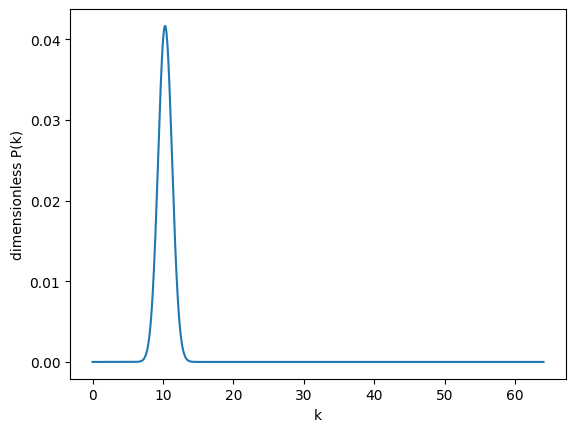

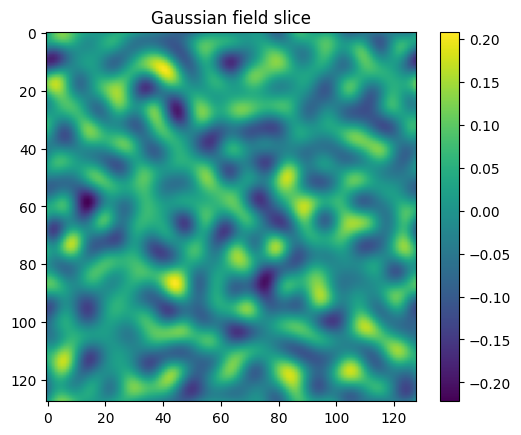

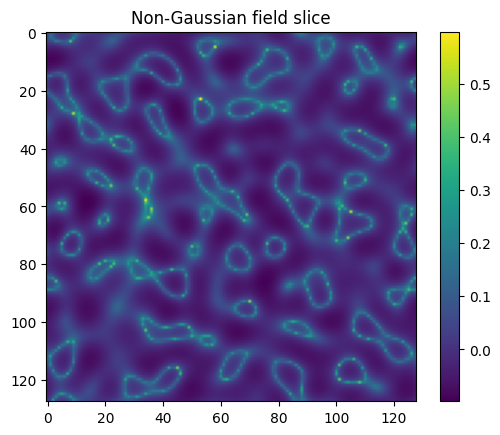

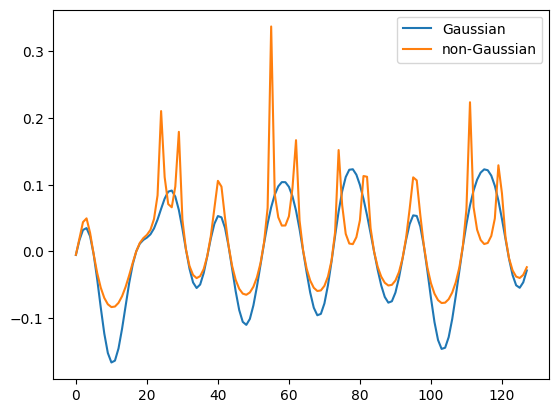

In [2]:
## generate the initial field (\Phi)

phi_gaussian, phi_non_gaussian = sg.gaussian_random_fields(
    n = 128,
    power_spectrum=sg.gaussian_bump_power_spectrum,
    non_gaussianity=0.1,
    seed=1234,
    workers=-1,
    dtype=np.float64,
)

klist = np.linspace(0, 128 // 2, 1000)
power_values = sg.gaussian_bump_power_spectrum(klist) * klist**3 / (2 * np.pi**2)

plt.plot(klist, power_values)
plt.xlabel("k")
plt.ylabel("dimensionless P(k)")
plt.show()

plt.imshow(phi_gaussian[:, :, 128 // 2], cmap="viridis")
plt.colorbar()
plt.title("Gaussian field slice")
plt.show()

plt.imshow(phi_non_gaussian[:, :, 128 // 2], cmap="viridis")
plt.colorbar()
plt.title("Non-Gaussian field slice")
plt.show()

plt.plot(phi_gaussian[:, 128 // 2, 128 // 2], label="Gaussian")
plt.plot(phi_non_gaussian[:, 128 // 2, 128 // 2], label="non-Gaussian")
plt.legend()
plt.show()

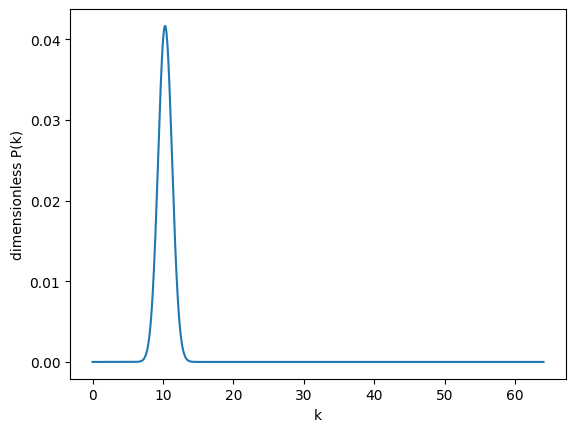

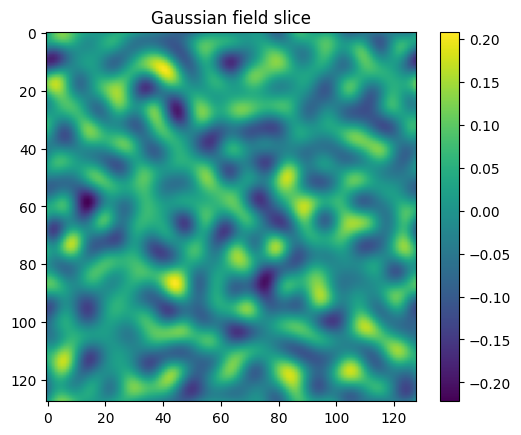

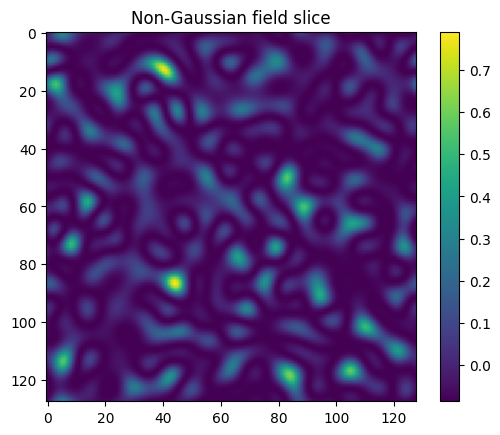

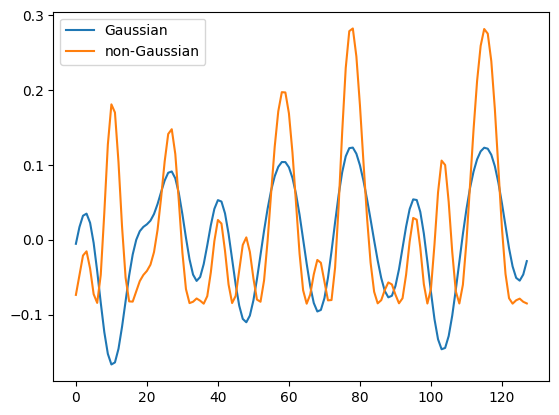

In [3]:
## You can also use your favorite dimensional power spectrum and non-gaussian transform

n = 128
dtype = np.float64

def my_power_spectrum(k):
    kstar = 10.0
    width = 0.1
    amplitude = 1.0e-2
    return (
        amplitude
        * (1.0 / kstar) ** 3
        / (np.sqrt(2.0 * np.pi) * width)
        * np.exp(-((k / kstar - 1.0) ** 2) / (2.0 * width**2))
        * (2.0 * np.pi**2)
    )


def my_non_gaussian_transform(zeta_g):
    return zeta_g + 10 * (zeta_g**2 - np.mean(zeta_g**2))

phi_gaussian, phi_non_gaussian = sg.gaussian_random_fields(
    n,
    power_spectrum=my_power_spectrum,
    non_gaussian_transform=my_non_gaussian_transform,
    seed=1234,
    workers=-1,
    dtype=dtype,
)

klist = np.linspace(0, n // 2, 1000)
power_values = sg.gaussian_bump_power_spectrum(klist) * klist**3 / (2 * np.pi**2)

plt.plot(klist, power_values)
plt.xlabel("k")
plt.ylabel("dimensionless P(k)")
plt.show()

plt.imshow(phi_gaussian[:, :, n // 2], cmap="viridis")
plt.colorbar()
plt.title("Gaussian field slice")
plt.show()

plt.imshow(phi_non_gaussian[:, :, n // 2], cmap="viridis")
plt.colorbar()
plt.title("Non-Gaussian field slice")
plt.show()

plt.plot(phi_gaussian[:, n // 2, n // 2], label="Gaussian")
plt.plot(phi_non_gaussian[:, n // 2, n // 2], label="non-Gaussian")
plt.legend()
plt.show()

FD final t: 3.140624999999955
Evolution Time:     0.9478954275449117 mins


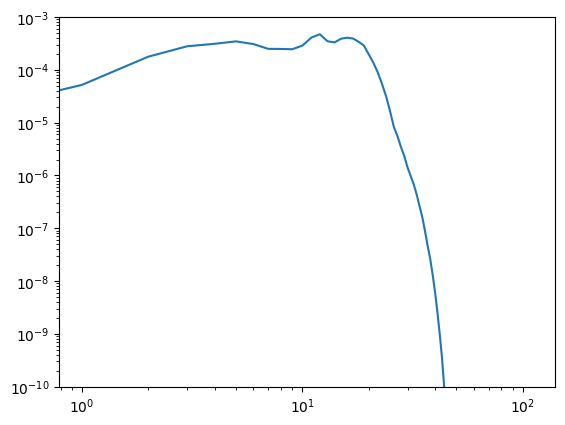

In [4]:
## using the finite-difference backend

dtype = np.float64  # use np.float32 for a faster, lower-precision FD run

## define your parameters

config = sg.EvolutionConfig(
    n=n,
    space_length=2.0,
    max_steps=1000,
    output_every=1000,
    output_path="log/test_1",
    workers=-1,
    fft_workers=1,
    fd_order=2, # finite-difference order: 2 or 4
    dtype=dtype,
    save_initial=False,
)

time_start = time.time()

state_fd = sg.run_evolution_fd(phi_non_gaussian, config, warmup=False)
print("FD final t:", state_fd.t)
print("Evolution Time:",'   ',(time.time()-time_start) / 60, 'mins')

spectra = sg.load_gw_spectra(
    [config.max_steps],
    raw_path=config.output_path,
    output_dir="GW_data",
    name="test_1",
    dt=config.dt,
    workers=config.workers,
)

# print(spectra[config.max_steps].shape)
plt.loglog(spectra[config.max_steps])
plt.ylim(1e-10, 1e-3)
plt.show()

FD final t: 3.140624999999955
Evolution Time:     13.769202558199565 mins


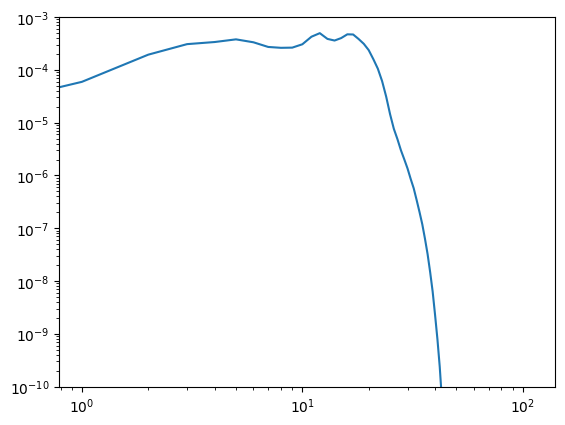

In [5]:
## using the CPU FFT backend

## define your parameters

config = sg.EvolutionConfig(
    n=n,
    space_length=2.0,
    max_steps=1000,
    output_every=1000,
    output_path="log/test_1",
    workers=-1,
    fft_workers=1,
    fd_order=2, # finite-difference order: 2 or 4
    dtype=dtype,
    save_initial=False,
)

time_start = time.time()
state_fft = sg.run_evolution(phi_non_gaussian, config)

print("FD final t:", state_fft.t)
print("Evolution Time:",'   ',(time.time()-time_start) / 60, 'mins')

spectra = sg.load_gw_spectra(
    [config.max_steps],
    raw_path=config.output_path,
    output_dir="GW_data",
    name="test_1",
    dt=config.dt,
    workers=config.workers,
)

# print(spectra[config.max_steps].shape)
plt.loglog(spectra[config.max_steps])
plt.ylim(1e-10, 1e-3)
plt.show()

FD final t: 3.140624999999955
Evolution Time:     1.5694088657697043 mins


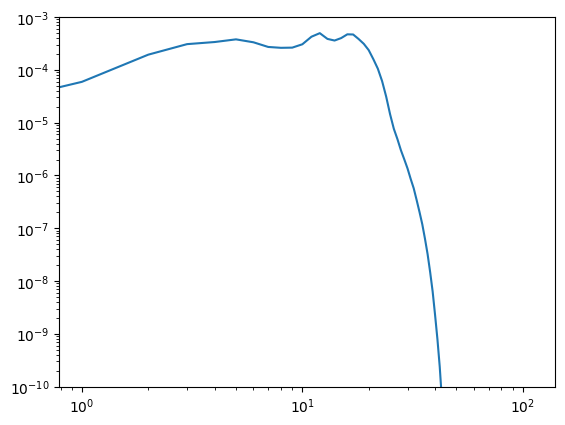

In [6]:
## using the PyTorch FFT method 

import torch

## define your parameters

config = sg.EvolutionConfig(
    n=n,
    space_length=2.0,
    max_steps=1000,
    output_every=1000,
    output_path="log/test_1",
    workers=-1,
    fft_workers=1,
    fd_order=2, # finite-difference order: 2 or 4
    dtype=dtype,
    save_initial=False,
)

time_start = time.time()
state_tc = sg.run_evolution_torch_fft(phi_non_gaussian, config, device="cuda", dtype=np.float64,
        clear_cache=False)

print("FD final t:", state_tc.t)
print("Evolution Time:",'   ',(time.time()-time_start) / 60, 'mins')

spectra = sg.load_gw_spectra(
    [config.max_steps],
    raw_path=config.output_path,
    output_dir="GW_data",
    name="test_1",
    dt=config.dt,
    workers=config.workers,
)

# print(spectra[config.max_steps].shape)
plt.loglog(spectra[config.max_steps])
plt.ylim(1e-10, 1e-3)
plt.show()